In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def posterior_density(x, y):
    mode1 = 3.0 * np.exp(-((x + 1.5)**2 + (y + 1.5)**2) / 0.4)
    mode2 = 2.5 * np.exp(-((x - 1.8)**2 + (y - 0.2)**2) / 0.4)
    mode3 = 2.8 * np.exp(-((x + 0.2)**2 + (y - 2.0)**2) / 0.4)
    
    minor_mode1 = 1.0 * np.exp(-((x - 1.0)**2 + (y + 1.8)**2) / 0.3)
    minor_mode2 = 0.8 * np.exp(-((x + 1.8)**2 + (y - 1.5)**2) / 0.3)
    
    base_density = 0.2 + 0.05 * np.sin(4 * x) * np.cos(4 * y)
    
    return mode1 + mode2 + mode3 + minor_mode1 + minor_mode2 + base_density

x = np.linspace(-3, 3, 150)
y = np.linspace(-3, 3, 150)
X, Y = np.meshgrid(x, y)
Z = posterior_density(X, Y)

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.75, antialiased=True, edgecolor='none', zorder=1)

cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
cbar.set_label(r'Posterior Density $P(\theta|\mathcal{D})$', rotation=90, labelpad=15, fontsize=12)

initializations = [
    (-2.8, -2.8, -1.5, -1.5, 'lightcoral', r'$\theta_1$ (Mode 1)'),   
    (2.8, -2.5, 1.8, 0.2, 'sandybrown', r'$\theta_2$ (Mode 2)'),     
    (-2.5, 2.8, -0.2, 2.0, 'orchid', r'$\theta_3$ (Mode 3)')         
]

np.random.seed(42)

for x_start, y_start, x_end, y_end, color, label in initializations:
    steps = 40 
    
    t = np.linspace(0, 1, steps)
    curve = 1 - (1 - t)**3 
    
    noise_envelope = 0.06 * (1 - t) 
    
    x_path = x_start + (x_end - x_start) * curve + np.random.normal(0, 1, steps) * noise_envelope
    y_path = y_start + (y_end - y_start) * curve + np.random.normal(0, 1, steps) * noise_envelope
    
    # DER FIX: Dynamischer Z-Offset!
    # Startet bei 0.15 (verhindert Clipping im Tal) und sinkt linear auf 0.02 ab.
    # Dadurch landet die Endkugel satt und physikalisch korrekt auf der Spitze.
    dynamic_z_offset = 0.15 * (1 - t) + 0.02 * t 
    
    z_path = posterior_density(x_path, y_path) + dynamic_z_offset
    
    ax.plot(x_path, y_path, z_path, color=color, linewidth=2.5, marker='.', markersize=4, alpha=0.9, zorder=10)
    
    # Startpunkt (Hat automatisch den Z-Offset von 0.15)
    ax.plot([x_path[0]], [y_path[0]], [z_path[0]], 
            color=color, marker='o', markersize=11, markeredgecolor='black', markeredgewidth=1.2, 
            linestyle='none', label=label, zorder=20)
    
    # Zielpunkt (Hat automatisch den Z-Offset von 0.02 -> sitzt perfekt auf dem Gipfel)
    ax.plot([x_path[-1]], [y_path[-1]], [z_path[-1]], 
            color='white', marker='o', markersize=7, markeredgecolor=color, markeredgewidth=2, 
            linestyle='none', zorder=20)

ax.set_title("Multimodal Posterior Distribution and MILE Initialization", fontsize=15, pad=20)
ax.set_xlabel(r"Network Parameter $\theta_1$", labelpad=10, fontsize=12)
ax.set_ylabel(r"Network Parameter $\theta_2$", labelpad=10, fontsize=12)
ax.set_zlabel(r"Probability Density $P(\theta|\mathcal{D})$", labelpad=10, fontsize=12)

ax.set_zlim(0, np.max(Z) + 0.5)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.view_init(elev=25, azim=-45)
ax.legend(fontsize=11, loc='upper right', framealpha=0.95)

plt.tight_layout()
# plt.savefig("mile_posterior_distribution.pdf", dpi=300, bbox_inches='tight')
plt.savefig("posterior_plot.pdf", dpi=300, bbox_inches='tight')
plt.show()

#### Create Plots for Dataset vs Epochs

In [6]:
from pathlib import Path
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(ROOT)
from src.Orchestration.ablation_metrics import (
    build_ablation_delta_series,
    format_metric_delta_assignments,
)

series = build_ablation_delta_series(
    visuals_root=ROOT / "src" / "visuals",
    baseline_table_map={
        "fiat": "fiat_500",
        "wine": "wine_quality",
        "healthcare": "healthcare_insurance",
        "miami": "miami_housing",
    },
    dataset_name_map={
        "fiat": "fiat500",
        "wine": "winequality",
        "healthcare": "healthinsurance",
        "miami": "miami_housing",
    },
    round_digits=4,
)

print(format_metric_delta_assignments(series, digits=4))

/Users/kingmopser/BachelorThesis/BachelorsThesisCode
data_rmse = {
    'fiat500': [0, 0, 0],
    'healthcare_insurance': [0, 0, 0],
    'miami_housing': [0, 0.1083, 0.1083],
    'wine_quality': [0, -0.6502, -0.6502],
}

data_nll = {
    'fiat500': [0, 0, 0],
    'healthcare_insurance': [0, 0, 0],
    'miami_housing': [0, 0.5396, 0.5396],
    'wine_quality': [0, -0.191, -0.191],
}

data_winkler = {
    'fiat500': [0, 0, 0],
    'healthcare_insurance': [0, 0, 0],
    'miami_housing': [0, -0.1681, -0.1681],
    'wine_quality': [0, -0.4867, -0.4867],
}

data_winklercoverage = {
    'fiat500': [0, 0, 0],
    'healthcare_insurance': [0, 0, 0],
    'miami_housing': [0, -0.0218, -0.0218],
    'wine_quality': [0, -0.0219, -0.0219],
}


In [ ]:
data_rmse = {
    'fiat500': [0, 0, 0],
    'healthcare_insurance': [0, 0, 0],
    'miami_housing': [0, 0.1083, 0.1083],
    'wine_quality': [0, -0.6502, -0.6502],
}

data_nll = {
    'fiat500': [0, 0, 0],
    'healthcare_insurance': [0, 0, 0],
    'miami_housing': [0, 0.5396, 0.5396],
    'wine_quality': [0, -0.191, -0.191],
}

data_winkler = {
    'fiat500': [0, 0, 0],
    'healthcare_insurance': [0, 0, 0],
    'miami_housing': [0, -0.1681, -0.1681],
    'wine_quality': [0, -0.4867, -0.4867],
}

data_winklercoverage = {
    'fiat500': [0, 0, 0],
    'healthcare_insurance': [0, 0, 0],
    'miami_housing': [0, -0.0218, -0.0218],
    'wine_quality': [0, -0.0219, -0.0219],
}

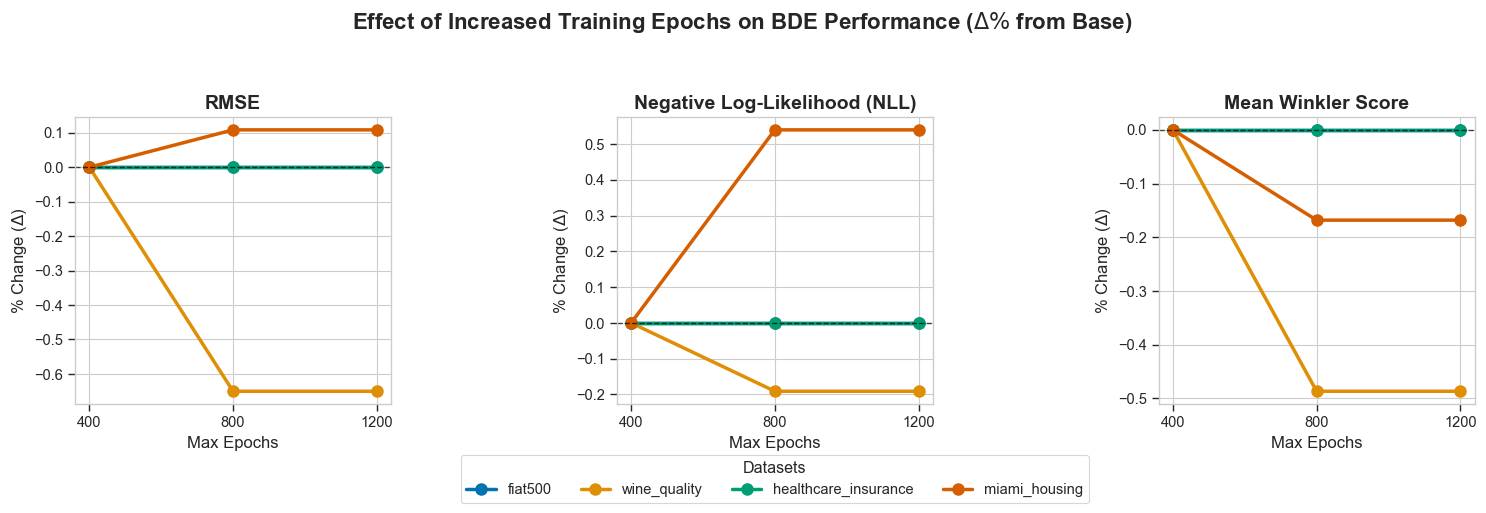

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ==========================================
# 1. Setup and Aesthetic Configuration
# ==========================================
# Use a clean style suitable for academic papers
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

# Define your datasets and the epoch intervals
datasets = ['fiat500', 'wine_quality', 'healthcare_insurance', 'miami_housing']
epochs = ['400', '800', '1200']

# Define a professional color palette (colorblind friendly is a bonus for theses!)
colors = sns.color_palette("colorblind", len(datasets))

# ==========================================
# 2. Dummy Data (Replace with your actual % change data!)
# ==========================================
# Format: Each list represents the % change from Base (which is always 0)
# for [Base, 800, 1200] epochs.
# Example: -2.0 means a 2% improvement (lower is better for all your metrics).
data_rmse = {
    'fiat500': [0, 0, 0],
    'healthcare_insurance': [0, 0, 0],
    'miami_housing': [0, 0.1083, 0.1083],
    'wine_quality': [0, -0.6502, -0.6502],
}

data_nll = {
    'fiat500': [0, 0, 0],
    'healthcare_insurance': [0, 0, 0],
    'miami_housing': [0, 0.5396, 0.5396],
    'wine_quality': [0, -0.191, -0.191],
}

data_winkler = {
    'fiat500': [0, 0, 0],
    'healthcare_insurance': [0, 0, 0],
    'miami_housing': [0, -0.1681, -0.1681],
    'wine_quality': [0, -0.4867, -0.4867],
}

data_winklercoverage = {
    'fiat500': [0, 0, 0],
    'healthcare_insurance': [0, 0, 0],
    'miami_housing': [0, -0.0218, -0.0218],
    'wine_quality': [0, -0.0219, -0.0219],
}
# ==========================================
# 3. Plotting Function
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
fig.suptitle('Effect of Increased Training Epochs on BDE Performance ($\Delta\%$ from Base)', 
             fontsize=16, fontweight='bold', y=1.05)

metrics = [('RMSE', data_rmse, axes[0]), 
           ('Negative Log-Likelihood (NLL)', data_nll, axes[1]), 
           ('Mean Winkler Score', data_winkler, axes[2])]

for metric_name, data_dict, ax in metrics:
    for idx, dataset in enumerate(datasets):
        ax.plot(epochs, data_dict[dataset], marker='o', linewidth=2.5, 
                markersize=8, label=dataset, color=colors[idx])
    
    # Formatting each subplot
    ax.set_title(metric_name, fontsize=14, fontweight='bold')
    ax.set_xlabel('Max Epochs', fontsize=12)
    ax.set_ylabel('% Change ($\Delta$)', fontsize=12)
    
    # Add a horizontal dashed line at 0 (the Base baseline)
    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    
    # Invert Y-axis if you want "Down" to visually mean "Better" 
    # (Since lower is better for RMSE, NLL, and Winkler)
    #ax.invert_yaxis() # Uncomment this if you want lines going down to indicate improvement

# Only add the legend to the middle plot to save space and reduce clutter
axes[1].legend(title="Datasets", loc='upper center', bbox_to_anchor=(0.5, -0.15), 
               ncol=4, frameon=True, fancybox=True, shadow=False)

plt.tight_layout()

# Save as PDF for high-quality LaTeX rendering
plt.savefig('epoch_ablation_plot.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("paper", font_scale=1.15)

epochs = ["400", "800", "1200"]
data_rmse = {
    'fiat500': [0, 0, 0],
    'healthcare_insurance': [0, 0, 0],
    'miami_housing': [0, 0.1083, 0.1083],
    'wine_quality': [0, -0.6502, -0.6502],
}

data_nll = {
    'fiat500': [0, 0, 0],
    'healthcare_insurance': [0, 0, 0],
    'miami_housing': [0, 0.5396, 0.5396],
    'wine_quality': [0, -0.191, -0.191],
}

data_winkler = {
    'fiat500': [0, 0, 0],
    'healthcare_insurance': [0, 0, 0],
    'miami_housing': [0, -0.1681, -0.1681],
    'wine_quality': [0, -0.4867, -0.4867],
}

data_winklercoverage = {
    'fiat500': [0, 0, 0],
    'healthcare_insurance': [0, 0, 0],
    'miami_housing': [0, -0.0218, -0.0218],
    'wine_quality': [0, -0.0219, -0.0219],
}

dataset_labels = {
    "fiat500": "Fiat 500",
    "healthcare_insurance": "Health Insurance",
    "wine_quality": "Wine Quality",
    "miami_housing": "Miami Housing",
}

dataset_groups = [
    ("Fiat 500 + Health Insurance", ["fiat500", "healthcare_insurance"]),
    ("Wine Quality + Miami Housing", ["wine_quality", "miami_housing"]),
]

metric_specs = [
    ("RMSE", data_rmse),
    ("Negative Log-Likelihood (NLL)", data_nll),
    ("Mean Winkler Score", data_winkler),
]

palette = sns.color_palette("colorblind", 4)
dataset_colors = {
    "fiat500": palette[0],
    "healthcare_insurance": palette[1],
    "wine_quality": palette[2],
    "miami_housing": palette[3],
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=False)
fig.suptitle(
    "Effect of Increased Training Epochs on BDE Performance ($\\Delta\\%$ from Baseline)",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

for row_idx, (group_title, datasets) in enumerate(dataset_groups):
    for col_idx, (metric_name, metric_data) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]

        for dataset in datasets:
            ax.plot(
                epochs,
                metric_data[dataset],
                marker="o",
                linewidth=2.5,
                markersize=7,
                label=dataset_labels[dataset],
                color=dataset_colors[dataset],
            )

        ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
        ax.set_title(metric_name, fontsize=13, fontweight="bold")
        ax.set_xlabel("Max Epochs")

        if col_idx == 0:
            ax.set_ylabel(f"{group_title}\n\n% Change ($\\Delta$)", fontsize=11)
        else:
            ax.set_ylabel("% Change ($\\Delta$)", fontsize=11)

        ax.tick_params(axis="both", labelsize=10)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=4,
    frameon=True,
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.savefig("epoch_ablation_plot_6panel.pdf", format="pdf", bbox_inches="tight")
plt.show()

#### This is for the Dataset Complextiy vs Hidden Layers


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ==========================================
# 1. Setup and Aesthetic Configuration
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.1)

architectures = ["[16,16]", "[32,32]", "[32,32,32]", "[16,16,16,16]"]
datasets = ['fiat500', 'healthcare_insurance', 'wine_quality', 'miami_housing']
colors = sns.color_palette("colorblind", len(datasets))

# ==========================================
# 2. Dummy Data (Replace with your actual metrics!)
# Format: List of 4 values [1L, 2L, 3L, 4L] for each dataset
# ==========================================
data_rmse = [
    [0.3944626687375909,0.3861456461641176, 0.3911289644432589, 0.39314994673040266],   # fiat500
    [0.4498986199675602,0.4495925517073077,0.4915042264710821,0.44747910320544515],    # insurance
    [0.7655152438269673, 0.7543914417309023, 0.7610974482170239, 0.7793275732977718],  # wine
    [0.30245815937873827, 0.31721759294855295, 0.3046928552556919,0.2850050259442642]    # miami
]

# Notice how NLL spikes on 4-layers for small data (Variance Overfitting!)
data_nll = [
    [0.40782657265663147, 0.43725648522377014,0.4082222580909729, 0.41318240761756897],     # fiat500 
    [141.40725708007812, 25.900348663330078, 0.6802657246589661,2.7609667778015137],     # insurance
    [1.1366194486618042,1.104927659034729, 1.1140403747558594, 1.1449558734893799],    # wine
    [-0.6608001589775085,-0.6596077084541321,-0.6574397683143616,-0.6900688409805298]      # miami
]

data_winkler = [
    [1.4669269323349, 1.5277472734451294, 1.4223235845565796, 1.42762291431427],     # fiat500
    [2.568767547607422, 2.707418441772461, 2.59110689163208, 2.609239101409912],     # insurance
    [3.194265604019165, 3.092755079269409,3.185035228729248, 3.296090841293335],     # wine
    [0.834879994392395, 0.8379188179969788,0.8098778128623962,0.7790091037750244]    # miami
]

# ==========================================
# 3. Plotting Function
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle('Effect of Hidden Layer Depth on Predictive and Distributional Performance', 
             fontsize=16, fontweight='bold', y=1.05)

metrics = [('RMSE', data_rmse, axes[0]), 
           ('Negative Log-Likelihood (NLL)', data_nll, axes[1]), 
           ('Mean Winkler Score', data_winkler, axes[2])]

x = np.arange(len(architectures))
width = 0.2

for metric_name, data_matrix, ax in metrics:
    multiplier = 0
    for idx, dataset_name in enumerate(datasets):
        offset = width * multiplier
        ax.bar(x + offset, data_matrix[idx], width, label=dataset_name, 
               color=colors[idx], edgecolor='black', linewidth=0.7)
        multiplier += 1
    
    # Formatting each subplot
    ax.set_title(metric_name, fontsize=14, fontweight='bold')
    ax.set_xlabel('Network Architecture', fontsize=12)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(architectures)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Only add the legend to the middle plot to keep it clean
axes[1].legend(title="Datasets", loc='upper center', bbox_to_anchor=(0.5, -0.15), 
               ncol=4, frameon=True, shadow=False)

plt.tight_layout()
plt.savefig('architecture_ablation_grid.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ==========================================
# 1. Setup and Aesthetic Configuration
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.1)

# X-Axis is now Datasets (Ordered strictly by complexity: Easiest to Hardest)
datasets = ['healthcare_insurance', 'fiat500', 'wine_quality', 'miami_housing']
architectures = ['[16, 16]', '[32, 32]', '[32, 32, 32]', '[16, 16, 16, 16]']

# Professional architecture-based color palette
colors = sns.color_palette("Blues", len(architectures))

# ==========================================
# 2. Your Data (REORDERED to match the new dataset list!)
# Format: [ [16,16], [32,32], [32,32,32], [16,16,16,16] ] 
# ==========================================
# NOTE: Paste your exact numbers here. I have rearranged the dummy arrays 
# so insurance is first, fiat is second, wine is third, miami is fourth.
data_rmse = [
    [0.3944626687375909,0.3861456461641176, 0.3911289644432589, 0.39314994673040266],   # fiat500
    [0.4498986199675602,0.4495925517073077,0.4915042264710821,0.44747910320544515],    # insurance
    [0.7655152438269673, 0.7543914417309023, 0.7610974482170239, 0.7793275732977718],  # wine
    [0.30245815937873827, 0.31721759294855295, 0.3046928552556919,0.2850050259442642]    # miami
]

# Notice how NLL spikes on 4-layers for small data (Variance Overfitting!)
data_nll = [
    [0.40782657265663147, 0.43725648522377014,0.4082222580909729, 0.41318240761756897],     # fiat500 
    [141.40725708007812, 25.900348663330078, 0.6802657246589661,2.7609667778015137],     # insurance
    [1.1366194486618042,1.104927659034729, 1.1140403747558594, 1.1449558734893799],    # wine
    [-0.6608001589775085,-0.6596077084541321,-0.6574397683143616,-0.6900688409805298]      # miami
]

data_winkler = [
    [1.4669269323349, 1.5277472734451294, 1.4223235845565796, 1.42762291431427],     # fiat500
    [2.568767547607422, 2.707418441772461, 2.59110689163208, 2.609239101409912],     # insurance
    [3.194265604019165, 3.092755079269409,3.185035228729248, 3.296090841293335],     # wine
    [0.834879994392395, 0.8379188179969788,0.8098778128623962,0.7790091037750244]    # miami
]

# Transpose the data so rows become architectures and columns become datasets
data_rmse_T = np.array(data_rmse).T
data_nll_T = np.array(data_nll).T
data_winkler_T = np.array(data_winkler).T

# ==========================================
# 3. Plotting Function
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)
fig.suptitle('Effect of Architecture Depth relative to Dataset Complexity', 
             fontsize=16, fontweight='bold', y=1.05)

metrics = [('RMSE', data_rmse_T, axes[0], False), 
           ('Negative Log-Likelihood (NLL)', data_nll_T, axes[1], True), # Log Scale for NLL
           ('Mean Winkler Score', data_winkler_T, axes[2], False)]

x = np.arange(len(datasets))
width = 0.2

for metric_name, data_matrix, ax, use_log in metrics:
    multiplier = 0
    # Loop through architectures to plot them
    for idx, arch_name in enumerate(architectures):
        offset = width * multiplier
        ax.bar(x + offset, data_matrix[idx], width, label=arch_name, 
               color=colors[idx], edgecolor='black', linewidth=0.7)
        multiplier += 1
    
    # Formatting each subplot
    ax.set_title(metric_name, fontsize=14, fontweight='bold')
    
    # === THE FIX: Vertical X-Axis Labels ===
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(datasets, fontsize=12, rotation=90) 
    
    # Apply Log Scale to NLL to prevent squashing
    if use_log:
        ax.set_yscale('symlog', linthresh=0.1)
        ax.set_ylabel('Log Scale', fontsize=10)
    else:
        ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add the legend to the middle plot
axes[1].legend(title="Network Architecture", loc='upper center', bbox_to_anchor=(0.5, -0.35), 
               ncol=4, frameon=True, shadow=False)

plt.tight_layout()
plt.savefig('architecture_complexity_vertical.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ==========================================
# 1. Setup and Aesthetic Configuration
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.1)

# FIXED: Reordered to match your actual data rows!
datasets = ['fiat500', 'healthcare_insurance', 'wine_quality', 'miami_housing']

# We still define all 4 to keep the color palette consistent, 
# but we will only PLOT the last 3.
all_architectures = ['[16, 16]', '[32, 32]', '[32, 32, 32]', '[16, 16, 16, 16]']
colors = sns.color_palette("Blues", 4)

# ==========================================
# 2. Data Definition
# ==========================================
data_rmse = [
    [0.3944626687375909,0.3861456461641176, 0.3911289644432589, 0.39314994673040266],   # fiat500
    [0.4498986199675602,0.4495925517073077,0.4915042264710821,0.44747910320544515],    # insurance
    [0.7655152438269673, 0.7543914417309023, 0.7610974482170239, 0.7793275732977718],  # wine
    [0.30245815937873827, 0.31721759294855295, 0.3046928552556919,0.2850050259442642]    # miami
]

# Notice how NLL spikes on 4-layers for small data (Variance Overfitting!)
data_nll = [
    [0.40782657265663147, 0.43725648522377014,0.4082222580909729, 0.41318240761756897],     # fiat500 
    [141.40725708007812, 25.900348663330078, 0.6802657246589661,2.7609667778015137],     # insurance
    [1.1366194486618042,1.104927659034729, 1.1140403747558594, 1.1449558734893799],    # wine
    [-0.6608001589775085,-0.6596077084541321,-0.6574397683143616,-0.6900688409805298]      # miami
]

data_winkler = [
    [1.4669269323349, 1.5277472734451294, 1.4223235845565796, 1.42762291431427],     # fiat500
    [2.568767547607422, 2.707418441772461, 2.59110689163208, 2.609239101409912],     # insurance
    [3.194265604019165, 3.092755079269409,3.185035228729248, 3.296090841293335],     # wine
    [0.834879994392395, 0.8379188179969788,0.8098778128623962,0.7790091037750244]    # miami
]


data_rmse_T = np.array(data_rmse).T
data_nll_T = np.array(data_nll).T
data_winkler_T = np.array(data_winkler).T

# ==========================================
# 3. Delta Calculation 
# ==========================================
def calculate_delta(data_matrix):
    baseline = data_matrix[0, :]
    return ((data_matrix - baseline) / np.abs(baseline)) * 100

delta_rmse = calculate_delta(data_rmse_T)
delta_nll = calculate_delta(data_nll_T)
delta_winkler = calculate_delta(data_winkler_T)

# ==========================================
# 4. Plotting Function
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)
fig.suptitle('Effect of Architecture Depth relative to [16, 16] Baseline ($\Delta$% change)', 
             fontsize=16, fontweight='bold', y=1.05)

metrics = [
    ('RMSE', delta_rmse, axes[0]), 
    ('Negative Log-Likelihood (NLL)', delta_nll, axes[1]), 
    ('Mean Winkler Score', delta_winkler, axes[2])
]

x = np.arange(len(datasets))
width = 0.2

for metric_name, data_matrix, ax in metrics:
    multiplier = 0
    # FIXED: Start loop at index 1 to skip the invisible [16, 16] baseline bar
    for idx in range(1, 4):
        offset = width * multiplier
        ax.bar(x + offset, data_matrix[idx], width, label=all_architectures[idx], 
               color=colors[idx], edgecolor='black', linewidth=0.7)
        multiplier += 1
    
    ax.set_title(metric_name, fontsize=14, fontweight='bold')
    ax.set_ylabel('% Change ($\Delta$)', fontsize=11)
    
    # FIXED: Re-center the ticks for 3 bars instead of 4
    ax.set_xticks(x + width)
    ax.set_xticklabels(datasets, fontsize=12, rotation=45, ha="right") 
    
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Legend updated to only show the plotted architectures
axes[1].legend(title="Network Architecture (vs. [16, 16])", loc='upper center', 
               bbox_to_anchor=(0.5, -0.25), ncol=3, frameon=True, shadow=False)

plt.tight_layout()
plt.savefig('architecture_complexity_delta_fixed.pdf', format='pdf', bbox_inches='tight')
plt.show()